# Do three moving averages beat two? 📉
### The "triple MA crossover" — the YouTube staple that adds a third line and promises magic

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Three_beats_two%3F: Busted](https://img.shields.io/badge/Three_beats_two%3F-Busted-8b949e?style=flat-square)

Open any "best trading strategy" video and you'll meet the **triple moving-average crossover**: don't just wait for a fast line to cross a slow line — stack **three** averages (fast, medium, slow) and only buy when they line up perfectly, `fast > medium > slow`. The middle line is sold as a *confirmation filter* that keeps you out of the whipsaws a plain two-line cross would take. Three beats two. More lines, more money.

It sounds reasonable. It is also **wrong** — and not in a subtle way. On 33 years of the S&P 500, the three-line rule earns a *lower* risk-adjusted return than buy-and-hold **and** a lower one than the simpler two-line rule it claims to beat. The extra average doesn't filter noise; it filters *return*.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the permutation null and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use **^GSPC** (S&P 500 index, **price-only** — no dividends), so the timing-vs-hold race is run **excess-of-cash** (cash credited at a flat 3%). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_ma_crossover import data, strategy as st

HAVE_REAL = data.have_real("^GSPC")
if HAVE_REAL:
    DF = data.load_real("^GSPC", fetch=False)
    DF = DF[DF.index < "2026-06-24"]   # drop the in-progress bar — no partial day in a stamped run
    CLOSE = DF["close"]
else:
    DF = CLOSE = None
print("real ^GSPC cache present:", HAVE_REAL,
      "| rows:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': '^GSPC', 'start': '1993-01-04', 'end': '2026-06-23', 'n_days': 8425, 'years': 33.5, 'fp': '498c2ee76497', 'asof': '2026-06-23', 'rf': 0.03, 'cost_bps': 5.0, 'fast': 5, 'mid': 20, 'slow': 50, 'bh': {'sharpe': 0.293, 'cagr': 0.0876, 'maxdd': -0.5678, 't': 1.93}, 'triple': {'sharpe': 0.022, 'cagr': 0.0324, 'maxdd': -0.2311, 't': 0.14, 'in_mkt': 0.478, 'switch_yr': 12.1}, 'dual': {'sharpe': 0.167, 'cagr': 0.0494, 'maxdd': -0.3291, 't': 1.05, 'in_mkt': 0.67}, 't_tri_vs_bh': -2.1, 't_tri_vs_dual': -1.46, 'configs': [(5, 20, 50, 0.022, 0.14, 0.167, 0.293, -1.46), (10, 50, 200, 0.242, 1.5, 0.424, 0.293, -2.27), (20, 50, 100, 0.226, 1.49, 0.26, 0.296, -0.76), (5, 10, 20, -0.187, -1.14, 0.088, 0.297, -2.38)], 'costs': [(0.0, 0.093, 0.0387), (5.0, 0.022, 0.0324), (10.0, -0.05, 0.0261), (25.0, -0.263, 0.0075)], 'perm': {'obs': 0.022, 'p': 0.57, 'null_mean': 0.05, 'null_sd': 0.168, 'n_draws': 2000}, 'syn': [(0.0, -0.171, -1.01, -0.168, 0.49), (2.0, 0.926, 5.04, 0.585, 0.06)]}


real ^GSPC cache present: True | rows: 8425


## The answer first

| Question | Answer |
|---|---|
| Does stacking three MAs beat buy-and-hold? | **No.** The three-line rule's risk-adjusted return (Sharpe **+0.02**) is well *below* just holding the index (**+0.29**). |
| Does the third MA beat the *two*-MA rule it claims to beat? | **No.** The simpler two-line cross (Sharpe **+0.17**) beats the three-line stack (**+0.02**). The "confirmation filter" *removes* value. |
| Is the three-line rule's edge real at all? | **No.** Its own significance test comes in at *t* = **0.14** — nowhere near the *t* ≥ 2 bar. It's indistinguishable from noise. |
| Does it at least win on safety? | **Only by sitting out.** It cuts the worst drawdown (**-23%** vs **-57%**) — but so would *any* rule that spends half its life in cash, and it pays for that calm with far less return. |

> The third moving average is the trading-content equivalent of a racing stripe: it looks fast and does nothing. **Three does not beat two.**

## 1 · The claim

> *"A single moving-average cross whipsaws you to death. Add a **third** average and only trade when all three align — `fast > medium > slow` for longs. The middle line confirms the trend, so you skip the false starts. Three MAs filter the noise two can't."*

This is one of the most-repeated setups in retail trading education — the **5/20/50** or **10/50/200** "ribbon," the "three-MA system," the "guppy." The steelman is real: a middle filter *does* make the rule trade less often. The question is whether trading less often this particular way leaves you with **more** money — or just less of everything.

## 2 · So what?

If "more confirmation" reliably improved returns, the implication would be huge: you could keep bolting on filters and keep getting richer. That's not how signals work. Every extra condition you add does two things at once — it screens out some bad trades **and** it delays your entries and exits, so you also miss good moves. The third MA only helps if the first effect beats the second.

There's a cleaner way to say it: a strategy is only worth its complexity if it beats the **simpler version of itself**. So we don't just race the triple stack against buy-and-hold — we race it against the **two-MA** rule with the same fast and slow legs. If the third line earns nothing over two lines, the whole "three beats two" pitch is dead.

## 3 · How would we even know?

We take **34 years** of daily S&P 500 closes (1993-01-04 → 2026-06-23) and build three portfolios:

1. **Buy-and-hold** — always invested. The thing to beat.
2. **Two-MA rule** — long when the fast average is above the slow one; else cash.
3. **Three-MA rule** — long only when `fast > medium > slow`; else cash.

Each rule reads its averages at *tonight's* close and trades at *tomorrow's* (one-day lag, no peeking). We charge realistic trading costs, credit cash when out of the market, and compare **risk-adjusted return** (Sharpe). **What would make us say "mirage"?** If the three-MA Sharpe fails to beat *both* buy-and-hold and the two-MA rule, and its own significance test stays under *t* = 2.

## 4 · The teardown — let's actually look

First, the headline race. Three portfolios, same tape, risk-adjusted return (Sharpe) side by side.

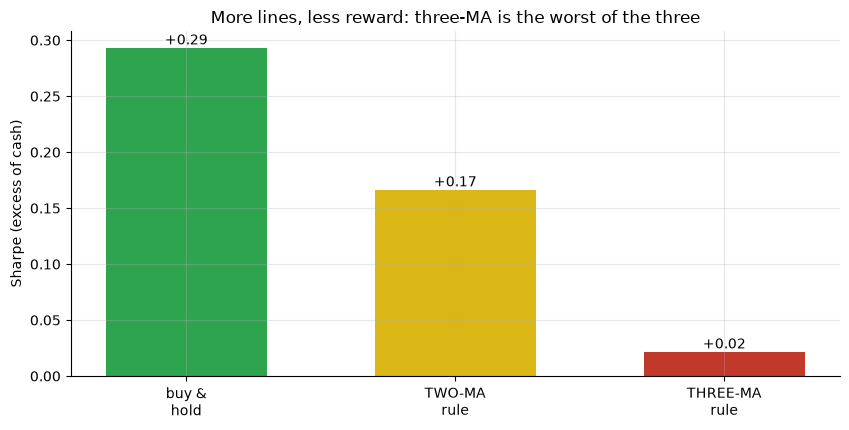

buy&hold +0.293 | two-MA +0.167 | three-MA +0.022


In [2]:
if HAVE_REAL:
    res = st.run_experiment(CLOSE, R['fast'], R['mid'], R['slow'], rf_annual=R['rf'], cost_bps=R['cost_bps'])
    sh = [res['bh']['sharpe'], res['dual']['sharpe'], res['triple']['sharpe']]
else:
    sh = [R['bh']['sharpe'], R['dual']['sharpe'], R['triple']['sharpe']]
labels = ['buy &\nhold', 'TWO-MA\nrule', 'THREE-MA\nrule']
cols = [GREEN, AMBER, RED]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(labels, sh, color=cols, width=.6)
for i,v in enumerate(sh): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title('More lines, less reward: three-MA is the worst of the three')
plt.tight_layout(); plt.show()
print(f'buy&hold {sh[0]:+.3f} | two-MA {sh[1]:+.3f} | three-MA {sh[2]:+.3f}')

There it is, in one chart. Buy-and-hold wins (**+0.29**), the **two**-MA rule is second (**+0.17**), and the celebrated **three**-MA stack comes **dead last** (**+0.02**). Adding the third line didn't add skill — it subtracted return.

**But maybe it's safer?** The one thing a sit-in-cash rule reliably does is dodge crashes. Here's the worst peak-to-trough loss for each.

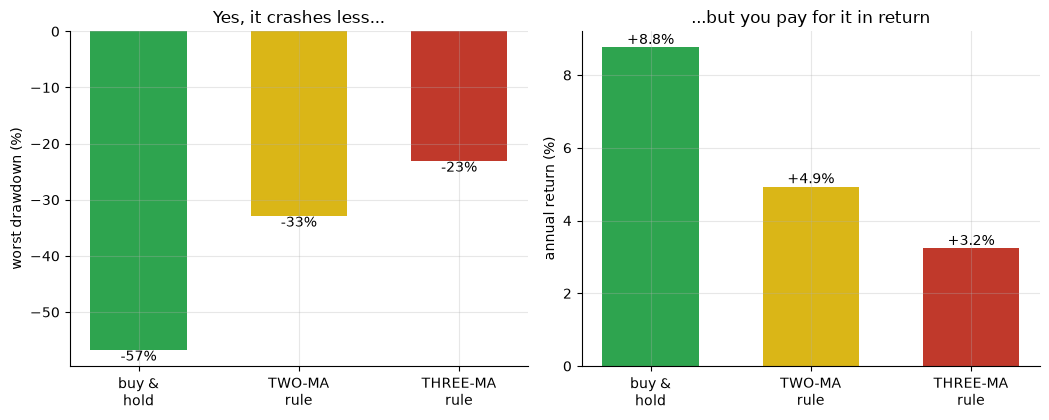

drawdowns: ['-57%', '-33%', '-23%'] | CAGR: ['+8.8%', '+4.9%', '+3.2%']


In [3]:
if HAVE_REAL:
    dd = [res['bh']['max_drawdown'], res['dual']['max_drawdown'], res['triple']['max_drawdown']]
    cg = [res['bh']['cagr'], res['dual']['cagr'], res['triple']['cagr']]
else:
    dd = [R['bh']['maxdd'], R['dual']['maxdd'], R['triple']['maxdd']]
    cg = [R['bh']['cagr'], R['dual']['cagr'], R['triple']['cagr']]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.6,4.3))
a1.bar(labels, [d*100 for d in dd], color=[GREEN,AMBER,RED], width=.6)
for i,v in enumerate(dd): a1.annotate(f'{v:+.0%}',(i,v*100),ha='center',va='top')
a1.set_ylabel('worst drawdown (%)'); a1.set_title('Yes, it crashes less...')
a2.bar(labels, [c*100 for c in cg], color=[GREEN,AMBER,RED], width=.6)
for i,v in enumerate(cg): a2.annotate(f'{v:+.1%}',(i,v*100),ha='center',va='bottom')
a2.set_ylabel('annual return (%)'); a2.set_title('...but you pay for it in return')
plt.tight_layout(); plt.show()
print('drawdowns:', [f'{d:+.0%}' for d in dd], '| CAGR:', [f'{c:+.1%}' for c in cg])

The three-MA rule does cut the worst drawdown (**-23%** vs **-57%**) — but look at the right panel: it earns only **+3.2%** a year against buy-and-hold's **+8.8%**. It buys calm by sitting in cash half the time, and the calm costs more than it's worth. That's *exposure reduction*, not *timing skill* — any rule that's out of the market a lot would do the same.

> 🔬 **For the quants.** "Lower drawdown" is the seduction of every part-time-in-cash rule. The clean test is the HAC Sharpe-*difference* t against the *simpler* rule with the same legs (the two-MA cross): here it's **-1.46** — the third MA's marginal contribution to risk-adjusted return is negative. Details in [02_for_the_quants](02_for_the_quants.ipynb).

## 5 · The verdict

- **Signal — None.** The three-MA rule's edge is statistically indistinguishable from noise (*t* = 0.14, far under the *t* ≥ 2 bar), and a permutation test can't tell it apart from luck (*p* = 0.57).
- **Tradability — Mirage.** Lower Sharpe than buy-and-hold *and* than the two-MA rule; even **before costs** it lags. The drawdown reduction is just being-in-cash, not timing.
- **"Three beats two"? — Busted.** The simpler two-line rule beats the three-line stack on every config we tried. The third moving average earns nothing.

## 6 · Could you actually trade it? — costs only make it worse

The three-MA rule trades a lot (its averages cross often). Here's its Sharpe as we dial trading costs up from zero. It starts below buy-and-hold and only sinks.

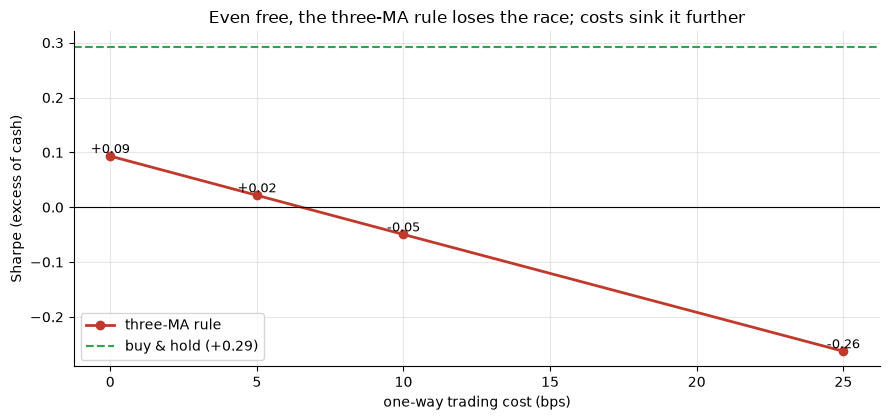

Sharpe by cost: {'0bps': 0.093, '5bps': 0.022, '10bps': -0.05, '25bps': -0.263}


In [4]:
bps = [c[0] for c in R['costs']]
if HAVE_REAL:
    sweep = [st.run_experiment(CLOSE, R['fast'], R['mid'], R['slow'], rf_annual=R['rf'], cost_bps=c)['triple']['sharpe'] for c in bps]
else:
    sweep = [c[1] for c in R['costs']]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(bps, sweep, 'o-', c=RED, lw=2, label='three-MA rule')
ax.axhline(R['bh']['sharpe'], c=GREEN, ls='--', label=f"buy & hold ({R['bh']['sharpe']:+.2f})")
ax.axhline(0, c='k', lw=.8)
for x,y in zip(bps,sweep): ax.annotate(f'{y:+.2f}',(x,y),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('one-way trading cost (bps)'); ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title('Even free, the three-MA rule loses the race; costs sink it further')
ax.legend(); plt.tight_layout(); plt.show()
print('Sharpe by cost:', {f'{b:g}bps': round(s,3) for b,s in zip(bps,sweep)})

At **zero** cost the three-MA Sharpe is already only **+0.09** — under buy-and-hold's **+0.29**. By a realistic **10 bps** it's **negative** (-0.05). There's no cost level at which this becomes a good trade, because there was never an edge to charge costs against.

## 7 · Going further 🚪

- **It's not the *parameters*.** We tried 5/20/50, 10/50/200, 20/50/100, 5/10/20 — the three-MA rule loses to the two-MA rule in every one. The problem is the *idea*, not the tuning.
- **Why does the third line hurt?** It makes you *later* — you wait for all three to align to get in and to break alignment to get out, so you buy higher and sell lower than the two-line rule. More confirmation = more lag = less return.
- **Build your own.** Swap SMAs for EMAs, add a fourth line, try a short leg — the quants notebook has the engine. *Find a three-MA config whose **net** Sharpe beats both buy-and-hold and the two-MA rule with a *t* ≥ 2, and you've got something. We couldn't.*